In [1]:
# importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
df=pd.read_csv(r"C:\Users\Lenovo\Documents\My Projects only\AI-Indent_calling\Dataset\function_calling_ai_dataset_1500.csv")

Data check

In [3]:
df.describe

<bound method NDFrame.describe of                               prompt              intent
0         quickly i want to call mom           open_call
1          can you flashlight please     open_flashlight
2         hmm make a phone call ring           open_call
3             quickly start playlist          open_music
4             sleep tracking section  open_sleep_tracker
...                              ...                 ...
1495  set alarm for 30 minutes alarm          open_alarm
1496         lets go jogging running        open_running
1497                 help me do math     open_calculator
1498                  contact office           open_call
1499            quickly track my run        open_running

[1500 rows x 2 columns]>

In [4]:
df.isnull().sum()

prompt    0
intent    0
dtype: int64

In [5]:
df.intent.value_counts()

intent
open_call             180
open_music            180
open_flashlight       170
open_alarm            170
open_camera           160
open_mail             150
open_calculator       140
open_running          130
open_sleep_tracker    120
open_water_tracker    100
Name: count, dtype: int64

In [6]:
df.head()

,prompt,intent
0,quickly i want to call mom,open_call
1,can you flashlight please,open_flashlight
2,hmm make a phone call ring,open_call
3,quickly start playlist,open_music
4,sleep tracking section,open_sleep_tracker


In [7]:
x=df.prompt
y=df.intent

----

Data splitting 

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

----

Implementing TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
vectorizer = TfidfVectorizer(
    lowercase=True,          # Convert text to lowercase
    stop_words="english",    # Remove common English words
    ngram_range=(1, 2),      # Use single words + word pairs
    max_features=5000        # Keep important features only
)

In [12]:
# Transform input training text data into numerical vectors
x_train_tfidf = vectorizer.fit_transform(x_train)

In [13]:
# Apply same transformation to input testing text data
x_test_tfidf = vectorizer.transform(x_test)

----

Model training 

In [14]:
from sklearn.svm import LinearSVC

In [15]:
model = LinearSVC()

In [16]:
model.fit(x_train_tfidf , y_train)

LinearSVC()

In [17]:
y_pred=model.predict(x_test_tfidf)

----

Model reports 

In [18]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [19]:
accuracy = accuracy_score(y_test , y_pred)

In [20]:
print(f"Accuracy : {accuracy}")

Accuracy : 1.0


In [21]:
print(classification_report(y_test , y_pred))

                    precision    recall  f1-score   support

        open_alarm       1.00      1.00      1.00        33
   open_calculator       1.00      1.00      1.00        35
         open_call       1.00      1.00      1.00        35
       open_camera       1.00      1.00      1.00        28
   open_flashlight       1.00      1.00      1.00        36
         open_mail       1.00      1.00      1.00        27
        open_music       1.00      1.00      1.00        37
      open_running       1.00      1.00      1.00        32
open_sleep_tracker       1.00      1.00      1.00        19
open_water_tracker       1.00      1.00      1.00        18

          accuracy                           1.00       300
         macro avg       1.00      1.00      1.00       300
      weighted avg       1.00      1.00      1.00       300



In [22]:
cm = confusion_matrix(y_test , y_pred)

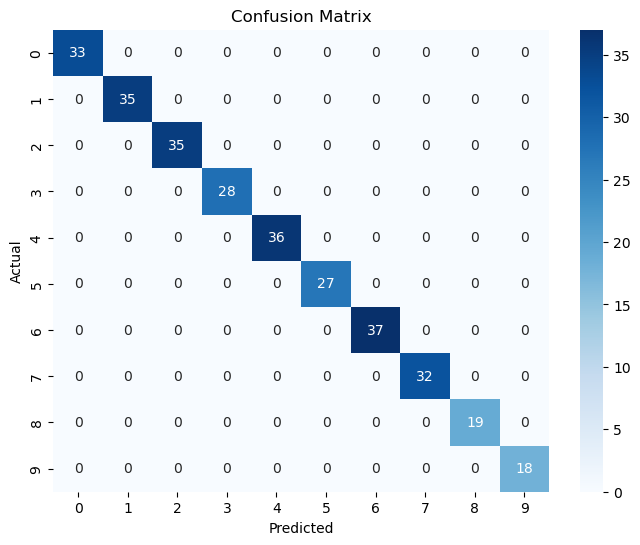

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(cm , annot = True , cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

----

Model testing 

In [24]:
test_commands = [

    # --------------------------
    # OPEN CALL
    # --------------------------
    "call my dad",
    "please dial rahul",
    "i want to make a phone call",
    "contact my friend",
    "can you call mom",

    # --------------------------
    # OPEN MAIL
    # --------------------------
    "send an email to professor",
    "open my inbox",
    "compose a mail",
    "i need to send mail",
    "please check emails",

    # --------------------------
    # OPEN CAMERA
    # --------------------------
    "open camera",
    "take a selfie",
    "click my picture",
    "i want to capture a photo",
    "start camera quickly",

    # --------------------------
    # OPEN MUSIC
    # --------------------------
    "play some songs",
    "start music",
    "i want to listen to music",
    "play my playlist",
    "put on some audio",

    # --------------------------
    # OPEN ALARM
    # --------------------------
    "set alarm for 6 am",
    "wake me tomorrow morning",
    "open alarm section",
    "start timer for 10 minutes",
    "i need an alarm",

    # --------------------------
    # OPEN CALCULATOR
    # --------------------------
    "calculate 55 plus 10",
    "open calculator",
    "solve this math problem",
    "help me calculate",
    "do some calculations",

    # --------------------------
    # OPEN RUNNING
    # --------------------------
    "start running",
    "lets go jogging",
    "track my run",
    "i want to go for a run",
    "begin jogging session",

    # --------------------------
    # OPEN WATER TRACKER
    # --------------------------
    "track my water intake",
    "log my hydration",
    "record how much water i drank",
    "show water tracker",
    "hydration section please",

    # --------------------------
    # OPEN SLEEP TRACKER
    # --------------------------
    "show sleep stats",
    "track my sleep",
    "monitor sleep quality",
    "check sleep duration",
    "sleep report please",

    # --------------------------
    # OPEN FLASHLIGHT
    # --------------------------
    "turn on flashlight",
    "switch on torch",
    "i need some light",
    "open flashlight",
    "make the room brighter",

    # --------------------------
    # HARD / TRICKY / UNSEEN
    # --------------------------
    "bro i need some light here",
    "hmm lets go for a morning jog",
    "please wake me up at 7",
    "i think i should drink more water",
    "can you help me with calculations",
    "need to send something by email",
    "quickly play some good music",
    "take my picture fast",
    "i wanna call someone",
    "show me how i slept"
]

In [25]:
# Convert commands to vectors
test_vectors = vectorizer.transform(test_commands)

In [26]:
# Predict intent
predictions = model.predict(test_vectors)

In [27]:
# Display results
for command, pred in zip(test_commands, predictions):
    print(f"Command: {command}")
    print(f"Predicted Intent: {pred}")
    print("-" * 50)

Command: call my dad
Predicted Intent: open_call
--------------------------------------------------
Command: please dial rahul
Predicted Intent: open_call
--------------------------------------------------
Command: i want to make a phone call
Predicted Intent: open_call
--------------------------------------------------
Command: contact my friend
Predicted Intent: open_call
--------------------------------------------------
Command: can you call mom
Predicted Intent: open_call
--------------------------------------------------
Command: send an email to professor
Predicted Intent: open_mail
--------------------------------------------------
Command: open my inbox
Predicted Intent: open_mail
--------------------------------------------------
Command: compose a mail
Predicted Intent: open_mail
--------------------------------------------------
Command: i need to send mail
Predicted Intent: open_mail
--------------------------------------------------
Command: please check emails
Predicted 

----

Model Dumping

In [28]:
import joblib

In [29]:
joblib.dump(model, "linear_svc_model.pkl")

['linear_svc_model.pkl']

In [30]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

-----